# Food Delivery Delay Analysis and Prediction

## Project Overview

In this project, we analyze a food delivery dataset to understand the main factors that affect delivery time and delayed orders. The goal is to explore customer orders, delivery distance, preparation time, traffic, weather, cancellations, refunds, and ratings, then identify useful business insights and build a basic prediction model for delayed deliveries.


## Business Problem

The business wants to understand why food deliveries are delayed and which factors have the strongest impact on delivery time. The goal is to analyze delivery performance, identify key delay drivers, and build a basic machine learning model to predict delayed deliveries.

In [79]:
!pip install pandas

In [80]:
import pandas as pd

In [81]:
df = pd.read_csv("food_delivery_analytics_cleaned.csv")

In [82]:
df.shape

(15000, 30)

In [83]:
df.head()

,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,...,111.563784,4,False,False,True,False,False,True,9,71.1
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,...,116.059264,7,False,False,False,True,False,False,12,100.0
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,...,111.708170,12,False,False,False,False,False,False,10,34.4
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,...,153.301345,7,False,False,False,False,True,True,1,45.0
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,...,111.128807,2,True,False,False,False,False,False,6,25.1


In [84]:
df.columns

Index(['order_id', 'city_tier', 'customer_age', 'customer_loyalty_score',
       'order_hour', 'order_day_of_week', 'order_month',
       'delivery_distance_km', 'preparation_time_minutes',
       'delivery_time_minutes', 'estimated_delivery_time',
       'traffic_level_score', 'weather_severity_score', 'restaurant_rating',
       'delivery_partner_rating', 'customer_rating', 'order_value',
       'delivery_fee', 'discount_amount', 'tip_amount', 'final_amount_paid',
       'number_of_items', 'cancellation_flag', 'delayed_delivery_flag',
       'refund_flag', 'promo_code_used', 'premium_customer_flag',
       'festival_or_weekend_flag', 'delivery_partner_experience_years',
       'delivery_efficiency_score'],
      dtype='object')

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   order_id                           15000 non-null  object 
 1   city_tier                          15000 non-null  int64  
 2   customer_age                       15000 non-null  int64  
 3   customer_loyalty_score             15000 non-null  float64
 4   order_hour                         15000 non-null  int64  
 5   order_day_of_week                  15000 non-null  int64  
 6   order_month                        15000 non-null  int64  
 7   delivery_distance_km               15000 non-null  float64
 8   preparation_time_minutes           15000 non-null  int64  
 9   delivery_time_minutes              15000 non-null  int64  
 10  estimated_delivery_time            15000 non-null  int64  
 11  traffic_level_score                15000 non-null  flo

In [86]:
df.isna().sum()

order_id                               0
city_tier                              0
customer_age                           0
customer_loyalty_score                 0
order_hour                             0
order_day_of_week                      0
order_month                            0
delivery_distance_km                   0
preparation_time_minutes               0
delivery_time_minutes                  0
estimated_delivery_time                0
traffic_level_score                    0
weather_severity_score                 0
restaurant_rating                      0
delivery_partner_rating              150
customer_rating                      150
order_value                            0
delivery_fee                           0
discount_amount                        0
tip_amount                           150
final_amount_paid                      0
number_of_items                        0
cancellation_flag                      0
delayed_delivery_flag                  0
refund_flag     

In [87]:
df.describe()

,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,...,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,delivery_partner_experience_years,delivery_efficiency_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,14850.000000,14850.000000,15000.000000,15000.000000,15000.000000,14850.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2.253133,46.569667,50.017658,11.470933,3.141933,6.474667,20.133756,32.749667,94.139267,94.140667,...,4.196121,3.993556,113.954265,7.493531,14.932581,12.569739,119.083685,6.489933,8.047600,59.165933
std,0.827951,16.840706,28.771665,6.946134,1.809864,3.454469,11.543488,16.162719,33.597132,32.490455,...,0.391959,0.535016,22.713411,4.352771,8.706253,7.221087,25.798587,3.438123,4.302995,18.102487
min,1.000000,18.000000,0.007172,0.000000,1.000000,1.000000,0.103086,5.000000,10.000000,11.000000,...,2.700000,1.500000,100.000000,0.000432,0.000788,0.000205,72.395550,1.000000,1.000000,1.900000
25%,2.000000,32.000000,25.199828,5.000000,1.000000,3.000000,10.133190,19.000000,68.000000,69.000000,...,3.900000,3.600000,100.000000,3.704018,7.279980,6.396828,101.152407,4.000000,4.000000,46.400000
50%,3.000000,46.000000,50.092268,11.000000,3.000000,7.000000,20.228709,33.000000,95.000000,94.000000,...,4.200000,4.000000,100.000000,7.458605,14.857607,12.629302,113.039544,7.000000,8.000000,59.100000
75%,3.000000,61.000000,74.840432,18.000000,5.000000,9.000000,30.047891,47.000000,120.000000,119.000000,...,4.500000,4.400000,124.153105,11.278689,22.521458,18.848336,130.541371,9.000000,12.000000,72.000000
max,3.000000,75.000000,99.989375,23.000000,6.000000,12.000000,39.998739,60.000000,180.000000,178.000000,...,5.000000,5.000000,215.614574,14.998370,29.999893,24.998828,238.600286,12.000000,15.000000,100.000000


## Basic KPI Summary

In [88]:
total_orders = len(df)
total_orders

15000

In [89]:
avg_delivery_time = df["delivery_time_minutes"].mean()
avg_delivery_time

np.float64(94.13926666666667)

In [90]:
delay_rate = df["delayed_delivery_flag"].mean() * 100
delay_rate

np.float64(9.466666666666667)

In [91]:
cancellation_rate = df["cancellation_flag"].mean() * 100
cancellation_rate

np.float64(13.353333333333333)

In [92]:
refund_rate = df["refund_flag"].mean() * 100
refund_rate

np.float64(4.12)

In [93]:
avg_final_amount_paid = df["final_amount_paid"].mean()
avg_final_amount_paid

np.float64(119.08368492543396)

In [94]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Average Delivery Time",
        "Delay Rate",
        "Cancellation Rate",
        "Refund Rate",
        "Average Final Amount Paid"
    ],
    "Value": [
        total_orders,
        round(avg_delivery_time, 2),
        round(delay_rate, 2),
        round(cancellation_rate, 2),
        round(refund_rate, 2),
        round(avg_final_amount_paid, 2)
    ]
})

kpi_summary

,Metric,Value
0,Total Orders,15000.00
1,Average Delivery Time,94.14
2,Delay Rate,9.47
3,Cancellation Rate,13.35
4,Refund Rate,4.12
5,Average Final Amount Paid,119.08


## Missing Values Treatment

In [95]:
df.isna().sum()

order_id                               0
city_tier                              0
customer_age                           0
customer_loyalty_score                 0
order_hour                             0
order_day_of_week                      0
order_month                            0
delivery_distance_km                   0
preparation_time_minutes               0
delivery_time_minutes                  0
estimated_delivery_time                0
traffic_level_score                    0
weather_severity_score                 0
restaurant_rating                      0
delivery_partner_rating              150
customer_rating                      150
order_value                            0
delivery_fee                           0
discount_amount                        0
tip_amount                           150
final_amount_paid                      0
number_of_items                        0
cancellation_flag                      0
delayed_delivery_flag                  0
refund_flag     

In [96]:
df_clean = df.copy()

In [97]:
df_clean["tip_amount"] = df_clean["tip_amount"].fillna(0)

In [98]:
df_clean["customer_rating"] = df_clean["customer_rating"].fillna(df_clean["customer_rating"].median())

In [99]:
df_clean["delivery_partner_rating"] = df_clean["delivery_partner_rating"].fillna(df_clean["delivery_partner_rating"].median())

In [100]:
df_clean.isna().sum()

order_id                             0
city_tier                            0
customer_age                         0
customer_loyalty_score               0
order_hour                           0
order_day_of_week                    0
order_month                          0
delivery_distance_km                 0
preparation_time_minutes             0
delivery_time_minutes                0
estimated_delivery_time              0
traffic_level_score                  0
weather_severity_score               0
restaurant_rating                    0
delivery_partner_rating              0
customer_rating                      0
order_value                          0
delivery_fee                         0
discount_amount                      0
tip_amount                           0
final_amount_paid                    0
number_of_items                      0
cancellation_flag                    0
delayed_delivery_flag                0
refund_flag                          0
promo_code_used          

## Feature Engineering

In [101]:
df_clean["delivery_delay_minutes"] = df_clean["delivery_time_minutes"] - df_clean["estimated_delivery_time"]

In [102]:
df_clean["is_late_by_time"] = df_clean["delivery_delay_minutes"] > 0

In [103]:
df_clean["distance_bucket"] = pd.cut(
    df_clean["delivery_distance_km"],
    bins=[0, 10, 20, 30, 40],
    labels=["0-10 km", "10-20 km", "20-30 km", "30-40 km"],
    include_lowest=True
)

In [104]:
df_clean[[
    "delivery_time_minutes",
    "estimated_delivery_time",
    "delivery_delay_minutes",
    "is_late_by_time",
    "delivery_distance_km",
    "distance_bucket"
]].head()

,delivery_time_minutes,estimated_delivery_time,delivery_delay_minutes,is_late_by_time,delivery_distance_km,distance_bucket
0,76,68,8,True,14.117144,10-20 km
1,34,40,-6,False,9.177354,0-10 km
2,152,142,10,True,34.753921,30-40 km
3,93,93,0,False,26.596184,20-30 km
4,141,134,7,True,26.204152,20-30 km


## Distance vs Delivery Time Analysis

In [105]:
df_clean[["delivery_distance_km", "delivery_time_minutes"]].corr()

,delivery_distance_km,delivery_time_minutes
delivery_distance_km,1.000000,0.863925
delivery_time_minutes,0.863925,1.000000


In [106]:
distance_analysis = df_clean.groupby("distance_bucket", observed=False).agg(
    orders=("order_id", "count"),
    avg_delivery_time=("delivery_time_minutes", "mean"),
    delay_rate=("delayed_delivery_flag", "mean"),
    avg_delay_minutes=("delivery_delay_minutes", "mean"),
    avg_customer_rating=("customer_rating", "mean")
).round(2)

distance_analysis

,orders,avg_delivery_time,delay_rate,avg_delay_minutes,avg_customer_rating
distance_bucket,,,,,
0-10 km,3697,56.31,0.09,-0.15,3.99
10-20 km,3709,81.09,0.09,0.06,3.99
20-30 km,3832,106.32,0.09,-0.08,3.99
30-40 km,3762,131.77,0.10,0.17,4.00


### Insight: Distance vs Delivery Time

The analysis shows that delivery time increases as delivery distance increases. Short-distance orders have lower average delivery time, while long-distance orders, especially 30-40 km, take much longer to deliver.

This means delivery distance is one of the strongest factors affecting delivery time. For business improvement, the company should set more realistic estimated delivery times for long-distance orders and optimize rider allocation for distant deliveries.


## Traffic Impact on Delivery Delay

In [107]:
df_clean["traffic_bucket"] = pd.cut(
    df_clean["traffic_level_score"],
    bins=[0, 3, 6, 10],
    labels=["Low Traffic", "Medium Traffic", "High Traffic"],
    include_lowest=True
)

In [108]:
traffic_analysis = df_clean.groupby("traffic_bucket", observed=False).agg(
    orders=("order_id", "count"),
    avg_delivery_time=("delivery_time_minutes", "mean"),
    delay_rate=("delayed_delivery_flag", "mean"),
    avg_delay_minutes=("delivery_delay_minutes", "mean")
).round(2)

traffic_analysis

,orders,avg_delivery_time,delay_rate,avg_delay_minutes
traffic_bucket,,,,
Low Traffic,4548,87.05,0.09,-0.04
Medium Traffic,4551,93.80,0.10,0.17
High Traffic,5901,99.86,0.09,-0.10


### Insight: Traffic Impact

The analysis shows that average delivery time increases as traffic level increases. Low traffic orders take around 87 minutes on average, while high traffic orders take around 100 minutes.

However, the delay rate remains almost similar across traffic levels. This suggests that traffic increases actual delivery time, but the estimated delivery system may already be adjusting expected delivery time for high traffic conditions.

## Weather Impact on Delivery Delay

In [109]:
df_clean["weather_bucket"] = pd.cut(
    df_clean["weather_severity_score"],
    bins=[0, 3, 6, 10],
    labels=["Good Weather", "Normal Weather", "Bad Weather"],
    include_lowest=True
)

In [110]:
weather_analysis = df_clean.groupby("weather_bucket", observed=False).agg(
    orders=("order_id", "count"),
    avg_delivery_time=("delivery_time_minutes", "mean"),
    delay_rate=("delayed_delivery_flag", "mean"),
    avg_delay_minutes=("delivery_delay_minutes", "mean")
).round(2)

weather_analysis

,orders,avg_delivery_time,delay_rate,avg_delay_minutes
weather_bucket,,,,
Good Weather,4594,88.52,0.09,-0.02
Normal Weather,4493,93.35,0.09,-0.11
Bad Weather,5913,99.11,0.10,0.10


### Insight: Weather Impact

The analysis shows that average delivery time increases as weather conditions become worse. Good weather orders take around 89 minutes on average, while bad weather orders take around 99 minutes.

The delay rate is slightly higher in bad weather, but the difference is not very large. This suggests that bad weather affects delivery speed, but estimated delivery times may already account for weather conditions.


## Order Hour Analysis

In [111]:
hour_analysis = df_clean.groupby("order_hour").agg(
    orders=("order_id", "count"),
    avg_delivery_time=("delivery_time_minutes", "mean"),
    delay_rate=("delayed_delivery_flag", "mean"),
    cancellation_rate=("cancellation_flag", "mean")
).round(2)

hour_analysis

,orders,avg_delivery_time,delay_rate,cancellation_rate
order_hour,,,,
0,659,94.08,0.08,0.16
1,626,93.42,0.08,0.13
2,618,91.47,0.09,0.14
3,639,91.69,0.10,0.13
4,592,94.58,0.09,0.13
5,641,95.33,0.11,0.16
6,633,93.07,0.09,0.11
7,630,94.96,0.09,0.15
8,632,93.64,0.08,0.14


In [112]:
hour_analysis.sort_values("avg_delivery_time", ascending=False).head(10)

,orders,avg_delivery_time,delay_rate,cancellation_rate
order_hour,,,,
21,634,96.00,0.11,0.15
22,645,95.85,0.12,0.13
20,613,95.52,0.10,0.12
11,625,95.46,0.09,0.11
5,641,95.33,0.11,0.16
18,648,94.99,0.09,0.12
15,594,94.98,0.10,0.14
7,630,94.96,0.09,0.15
10,646,94.84,0.09,0.12


### Insight: Order Hour Impact

The slowest delivery times are observed around evening and night hours, especially between 8 PM and 10 PM. Orders placed at 9 PM have the highest average delivery time of around 96 minutes.

This may indicate peak demand hours, higher rider workload, or restaurant preparation delays during busy periods. The business should consider improving rider allocation and restaurant coordination during evening peak hours.

## City Tier Analysis

In [113]:
city_analysis = df_clean.groupby("city_tier").agg(
    orders=("order_id", "count"),
    avg_delivery_time=("delivery_time_minutes", "mean"),
    delay_rate=("delayed_delivery_flag", "mean"),
    cancellation_rate=("cancellation_flag", "mean"),
    refund_rate=("refund_flag", "mean"),
    avg_customer_rating=("customer_rating", "mean"),
    avg_final_amount_paid=("final_amount_paid", "mean")
).round(2)

city_analysis

,orders,avg_delivery_time,delay_rate,cancellation_rate,refund_rate,avg_customer_rating,avg_final_amount_paid
city_tier,,,,,,,
1,3723,94.17,0.09,0.14,0.04,3.99,119.25
2,3757,93.72,0.09,0.13,0.05,3.99,118.64
3,7520,94.33,0.10,0.13,0.04,4.00,119.22


### Insight: City Tier Performance

The analysis shows that delivery performance is fairly similar across all city tiers. City Tier 3 has the highest number of orders and a slightly higher average delivery time and delay rate.

This suggests that Tier 3 cities may have higher order volume or operational load. The business should monitor Tier 3 delivery operations closely, especially during peak hours.

## Correlation Analysis

In [114]:
correlation_with_delivery_time = df_clean.select_dtypes(include="number").corr()["delivery_time_minutes"].sort_values(ascending=False)

correlation_with_delivery_time

delivery_time_minutes                1.000000
estimated_delivery_time              0.970722
delivery_distance_km                 0.863925
preparation_time_minutes             0.394064
delivery_delay_minutes               0.254973
traffic_level_score                  0.163487
weather_severity_score               0.136230
order_hour                           0.015096
customer_age                         0.007701
customer_rating                      0.006905
number_of_items                      0.004095
order_month                          0.004002
city_tier                            0.003181
delivery_partner_experience_years    0.002989
tip_amount                          -0.000489
delivery_fee                        -0.000611
discount_amount                     -0.004437
final_amount_paid                   -0.004645
delivery_partner_rating             -0.005915
customer_loyalty_score              -0.006855
order_value                         -0.007640
restaurant_rating                 

### Insight: Correlation with Delivery Time

Correlation analysis shows that delivery distance has the strongest operational relationship with delivery time. Preparation time also has a moderate positive relationship with delivery time, while traffic and weather have smaller but still noticeable effects.

Estimated delivery time is highly correlated with actual delivery time, but it should be interpreted carefully because it is already a system-generated estimate.

Delivery efficiency score has a strong negative correlation with delivery time, which means higher efficiency is associated with faster deliveries.

## Final EDA Summary and Business Recommendations

### Key Findings

1. Delivery distance is the strongest operational factor affecting delivery time.
2. Longer distance orders, especially 30-40 km, have much higher average delivery time.
3. Traffic and bad weather increase average delivery time, but delay rate remains relatively stable.
4. Evening peak hours, especially 8 PM to 10 PM, show slower delivery performance.
5. City Tier 3 has the highest order volume and slightly higher delay rate.
6. Higher delivery efficiency score is strongly associated with lower delivery time.

### Business Recommendations

1. Set more realistic estimated delivery times for long-distance orders.
2. Allocate more delivery partners during evening peak hours.
3. Monitor high-distance and bad-weather deliveries more closely.
4. Improve restaurant preparation workflows to reduce overall delivery time.
5. Focus on City Tier 3 operations because it has the highest order volume.
6. Use delivery efficiency score to identify high-performing and low-performing delivery operations.

# Data Visualization

In [115]:
!pip install matplotlib seaborn

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

## Distance Bucket vs Average Delivery Time

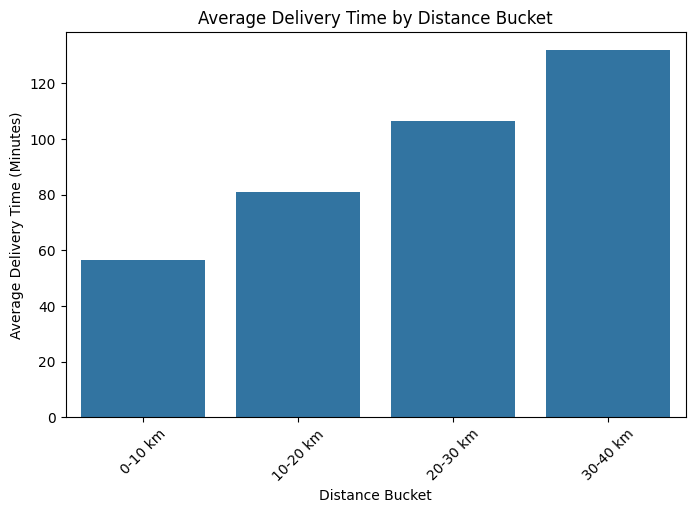

In [117]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=distance_analysis.reset_index(),
    x="distance_bucket",
    y="avg_delivery_time"
)

plt.title("Average Delivery Time by Distance Bucket")
plt.xlabel("Distance Bucket")
plt.ylabel("Average Delivery Time (Minutes)")
plt.xticks(rotation=45)
plt.show()

### Visualization Insight

The chart clearly shows that average delivery time increases as delivery distance increases. Orders in the 30-40 km range take the longest time to deliver, while orders within 0-10 km are delivered the fastest.

## Traffic Bucket vs Average Delivery Time

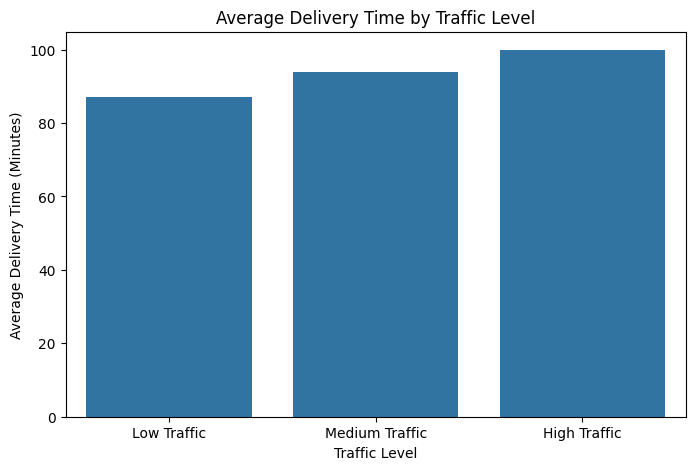

In [118]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=traffic_analysis.reset_index(),
    x="traffic_bucket",
    y="avg_delivery_time"
)

plt.title("Average Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (Minutes)")
plt.show()

### Visualization Insight

The chart shows that average delivery time increases as traffic level becomes higher. High traffic orders take more time on average compared to low and medium traffic orders.

## Weather Bucket vs Average Delivery Time

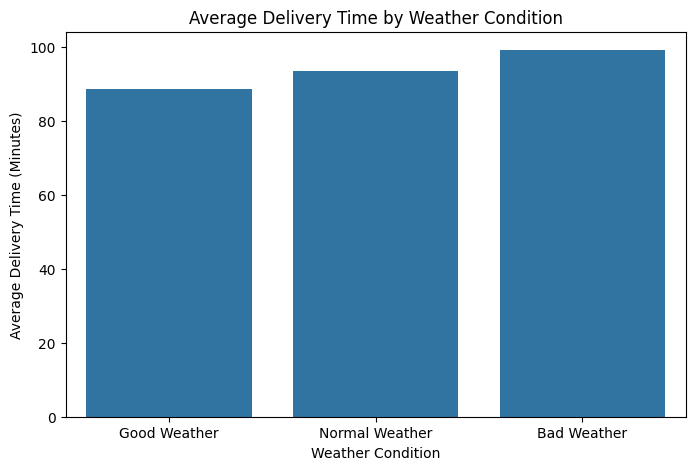

In [119]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=weather_analysis.reset_index(),
    x="weather_bucket",
    y="avg_delivery_time"
)

plt.title("Average Delivery Time by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Delivery Time (Minutes)")
plt.show()

### Visualization Insight

The chart shows that average delivery time increases as weather conditions get worse. Bad weather orders take longer on average compared to good and normal weather conditions.

## Order Hour vs Average Delivery Time

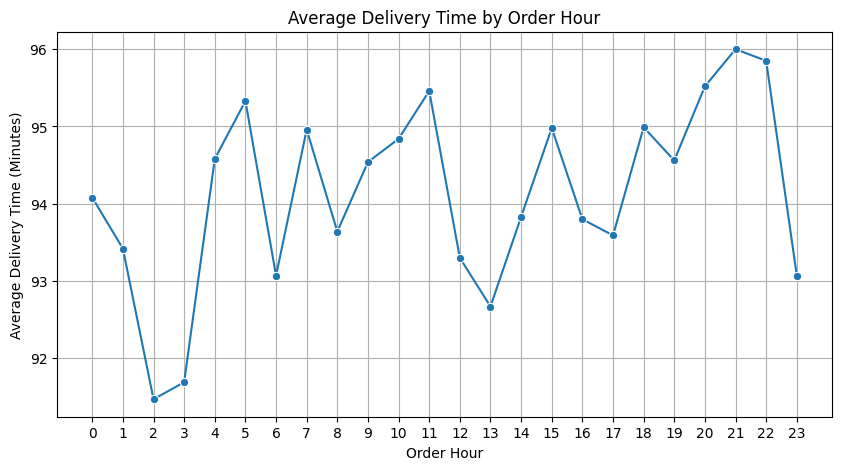

In [120]:
hour_analysis_sorted = hour_analysis.sort_index()

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hour_analysis_sorted,
    x=hour_analysis_sorted.index,
    y="avg_delivery_time",
    marker="o"
)

plt.title("Average Delivery Time by Order Hour")
plt.xlabel("Order Hour")
plt.ylabel("Average Delivery Time (Minutes)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

### Visualization Insight

The line chart shows that average delivery time varies across different hours of the day. The highest delivery times are observed during evening and night hours, especially between 8 PM and 10 PM.

This suggests that evening peak hours may create more delivery pressure due to higher demand, restaurant workload, or rider availability issues.

## Correlation with Delivery Time

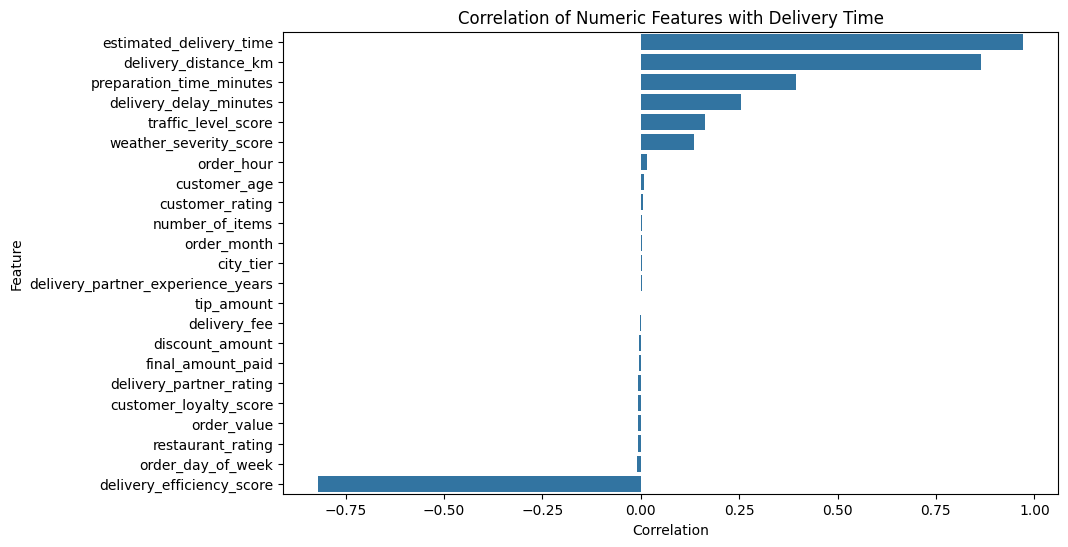

In [121]:
corr_delivery_time = df_clean.select_dtypes(include="number").corr()["delivery_time_minutes"].sort_values(ascending=False)

corr_delivery_time = corr_delivery_time.drop("delivery_time_minutes")

plt.figure(figsize=(10, 6))

sns.barplot(
    x=corr_delivery_time.values,
    y=corr_delivery_time.index
)

plt.title("Correlation of Numeric Features with Delivery Time")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

### Visualization Insight

The correlation chart shows that the estimated delivery time has the strongest relationship with actual delivery time. However, since the estimated delivery time is already a system-generated prediction, it should not be treated as a root business cause.

Among operational factors, delivery distance has the strongest positive relationship with delivery time. Preparation time, traffic level, and weather severity also have positive relationships with delivery time.

The delivery efficiency score has a strong negative relationship with delivery time, meaning higher efficiency is associated with faster deliveries.


# Machine Learning Model

In [122]:
!pip install scikit-learn

In [123]:
import sklearn

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

## Model Goal

The goal of this machine learning model is to predict whether a delivery will be delayed or not.

In [125]:
y = df_clean["delayed_delivery_flag"]

In [126]:
features = [
    "city_tier",
    "customer_age",
    "customer_loyalty_score",
    "order_hour",
    "order_day_of_week",
    "order_month",
    "delivery_distance_km",
    "preparation_time_minutes",
    "traffic_level_score",
    "weather_severity_score",
    "restaurant_rating",
    "delivery_partner_rating",
    "order_value",
    "delivery_fee",
    "discount_amount",
    "number_of_items",
    "promo_code_used",
    "premium_customer_flag",
    "festival_or_weekend_flag",
    "delivery_partner_experience_years"
]

X = df_clean[features]

In [127]:
X.head()


,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,traffic_level_score,weather_severity_score,restaurant_rating,delivery_partner_rating,order_value,delivery_fee,discount_amount,number_of_items,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years
0,2,21,4.957522,20,6,6,14.117144,23,5.4,2.6,4.3,4.1,100.000000,14.592602,22.969359,4,False,False,True,9
1,1,63,38.744721,0,2,2,9.177354,16,1.0,1.6,4.0,4.2,100.000000,4.391720,4.434405,7,True,False,False,12
2,1,68,45.170997,9,2,11,34.753921,41,8.3,4.1,4.4,4.2,100.000000,9.006407,14.979691,12,False,False,False,10
3,2,30,10.573003,6,6,5,26.596184,9,3.2,8.8,4.8,4.6,145.113442,11.407034,14.813044,7,False,True,True,1
4,2,60,58.284620,12,1,9,26.204152,49,7.5,9.5,4.0,3.9,100.000000,11.572232,13.716308,2,False,False,False,6


In [128]:
y.head()

0    False
1    False
2    False
3    False
4    False
Name: delayed_delivery_flag, dtype: bool

## Train Test Split

In [129]:
from sklearn.model_selection import train_test_split

In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [131]:
X_train.shape, X_test.shape

((12000, 20), (3000, 20))

## Logistic Regression Model

In [132]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [133]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [134]:
y_pred = log_model.predict(X_test)

In [135]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9053333333333333

In [136]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

       False       0.91      1.00      0.95      2716
        True       0.00      0.00      0.00       284

    accuracy                           0.91      3000
   macro avg       0.45      0.50      0.48      3000
weighted avg       0.82      0.91      0.86      3000



In [137]:
confusion_matrix(y_test, y_pred)

array([[2716,    0],
       [ 284,    0]])

### Logistic Regression Result

The Logistic Regression model achieved around 91% accuracy, but this result is misleading because the dataset is imbalanced. The model predicted all test records as non-delayed and failed to identify any delayed deliveries.

This means accuracy alone is not a reliable metric for this problem. We need to focus on recall and F1-score for the delayed class.

## Logistic Regression with Class Balance

In [138]:
balanced_log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
balanced_log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [139]:
balanced_y_pred = balanced_log_model.predict(X_test)

In [140]:
print(classification_report(y_test, balanced_y_pred))

              precision    recall  f1-score   support

       False       0.91      0.54      0.68      2716
        True       0.10      0.50      0.17       284

    accuracy                           0.53      3000
   macro avg       0.51      0.52      0.42      3000
weighted avg       0.84      0.53      0.63      3000



In [141]:
confusion_matrix(y_test, balanced_y_pred)

array([[1456, 1260],
       [ 141,  143]])

### Balanced Logistic Regression Result

After applying class balancing, the model started identifying delayed deliveries. The recall for delayed deliveries improved from 0.00 to 0.50, meaning the model can now detect around half of the delayed orders.

However, overall accuracy dropped because the model also predicted many non-delayed orders as delayed. This shows the trade-off between detecting delayed orders and avoiding false alarms.

## Random Forest Model

In [142]:
from sklearn.ensemble import RandomForestClassifier

In [143]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [144]:
rf_y_pred = rf_model.predict(X_test)

In [145]:
print(classification_report(y_test, rf_y_pred, zero_division=0))

              precision    recall  f1-score   support

       False       0.91      1.00      0.95      2716
        True       0.00      0.00      0.00       284

    accuracy                           0.91      3000
   macro avg       0.45      0.50      0.48      3000
weighted avg       0.82      0.91      0.86      3000



In [146]:
confusion_matrix(y_test, rf_y_pred)

array([[2716,    0],
       [ 284,    0]])

### Random Forest Result

The Random Forest model also predicted all orders as non-delayed. Although the overall accuracy is around 91%, the model completely failed to identify delayed deliveries.

This confirms that the dataset is highly imbalanced and the delayed class is difficult to predict using the current features.

## Feature Importance

In [147]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
6,delivery_distance_km,0.081888
2,customer_loyalty_score,0.080267
14,discount_amount,0.078611
13,delivery_fee,0.077743
9,weather_severity_score,0.069773
8,traffic_level_score,0.067479
7,preparation_time_minutes,0.065589
1,customer_age,0.065226
3,order_hour,0.057396
11,delivery_partner_rating,0.051300


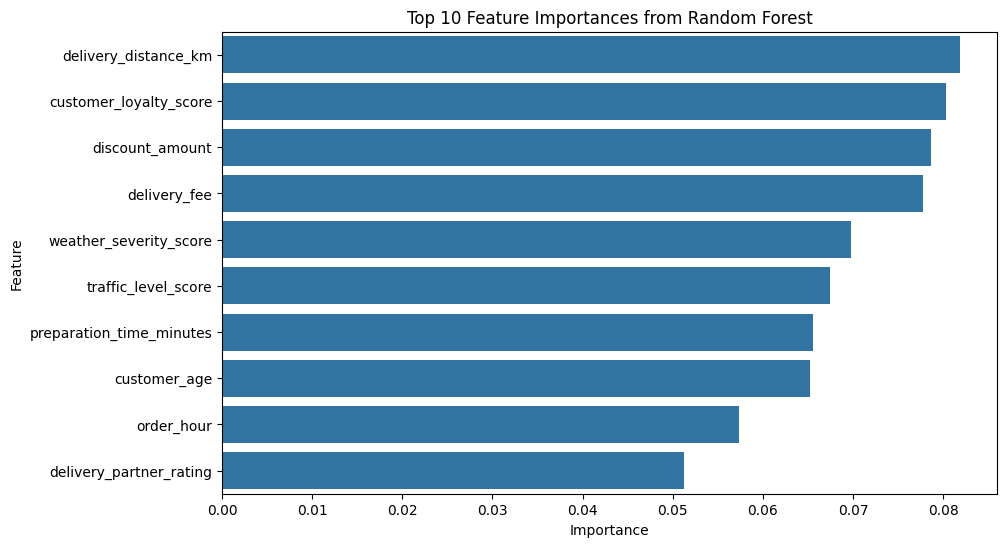

In [148]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Feature Importance Insight

The Random Forest feature importance chart shows that delivery distance is the most important feature in the model. This supports the earlier EDA finding that distance strongly affects delivery performance.

Other important features include customer loyalty score, discount amount, delivery fee, weather severity, traffic level, and preparation time. However, since the classification model struggled to detect delayed deliveries, these feature importance results should be treated as directional rather than final proof.

## Machine Learning Summary

The initial Logistic Regression and Random Forest models achieved high accuracy, but they failed to identify delayed deliveries because the dataset is imbalanced. Most orders are non-delayed, so the models learned to predict the majority class.

After applying class balancing to Logistic Regression, the model was able to detect around half of the delayed orders, but accuracy dropped due to more false positives.

This shows that accuracy alone is not enough for imbalanced classification problems. For delayed delivery prediction, recall and F1-score for the delayed class are more important metrics.

# Final Conclusion

This project analyzed a food delivery dataset to understand the main factors affecting delivery time and delayed orders. The analysis showed that delivery distance is the strongest operational factor affecting delivery time. Preparation time, traffic level, weather severity, and order hour also influence delivery performance.

The visualization section confirmed that longer distances, higher traffic levels, and bad weather conditions increase average delivery time. Evening hours, especially 8 PM to 10 PM, showed slightly higher delivery times.

Machine learning models showed that predicting delayed deliveries is challenging because the dataset is imbalanced. The balanced Logistic Regression model improved delayed-order recall, but also increased false positives.

Overall, the business should focus on optimizing long-distance deliveries, improving preparation workflows, allocating more delivery partners during evening peak hours, and adjusting estimated delivery times based on distance, traffic, and weather conditions.

## Limitations

The dataset is imbalanced because most orders are non-delayed. This made it difficult for machine learning models to correctly identify delayed deliveries. Also, some useful real-world factors such as rider availability, restaurant capacity, live traffic routes, and exact location data are not available in the dataset.